<a href="https://colab.research.google.com/github/SomyaSarswat/DemoJavaScript/blob/main/MLKNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predict the Type of Gamer (KNN)-Low, Medium or High Performance category


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import pandas as pd

data = {
    'Study_Hours': [
        1.0, 1.5, 2.0, 2.2, 2.5,
        3.0, 3.2, 3.5, 3.8, 4.0,
        4.2, 4.5, 4.8, 5.0, 5.2,
        5.5, 5.8, 6.0, 6.5, 7.0
    ],

    'Attendance': [
        55, 60, 62, 65, 68,
        70, 72, 75, 76, 78,
        80, 82, 84, 86, 88,
        90, 91, 93, 95, 97
    ],

    'Assignment_Score': [
        40, 45, 48, 50, 52,
        55, 58, 60, 62, 65,
        68, 70, 72, 75, 78,
        80, 83, 86, 90, 94
    ],

    'Sleep_Hours': [
        5.0, 5.5, 5.0, 6.0, 5.5,
        6.0, 6.5, 6.0, 6.5, 7.0,
        6.5, 7.0, 7.0, 7.5, 7.0,
        7.5, 8.0, 7.5, 8.0, 8.0
    ],

    'Performance': [
        'Low', 'Low', 'Low', 'Low', 'Low',
        'Medium', 'Medium', 'Medium', 'Medium', 'Medium',
        'Medium', 'Medium', 'Medium', 'High', 'High',
        'High', 'High', 'High', 'High', 'High'
    ]
}

df = pd.DataFrame(data)

print(df)

    Study_Hours  Attendance  Assignment_Score  Sleep_Hours Performance
0           1.0          55                40          5.0         Low
1           1.5          60                45          5.5         Low
2           2.0          62                48          5.0         Low
3           2.2          65                50          6.0         Low
4           2.5          68                52          5.5         Low
5           3.0          70                55          6.0      Medium
6           3.2          72                58          6.5      Medium
7           3.5          75                60          6.0      Medium
8           3.8          76                62          6.5      Medium
9           4.0          78                65          7.0      Medium
10          4.2          80                68          6.5      Medium
11          4.5          82                70          7.0      Medium
12          4.8          84                72          7.0      Medium
13    

# **Understand the Dataset**

In [ ]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())

Dataset shape: (20, 5)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Study_Hours       20 non-null     float64
 1   Attendance        20 non-null     int64  
 2   Assignment_Score  20 non-null     int64  
 3   Sleep_Hours       20 non-null     float64
 4   Performance       20 non-null     object 
dtypes: float64(2), int64(2), object(1)
memory usage: 932.0+ bytes
None

Statistical summary:
       Study_Hours  Attendance  Assignment_Score  Sleep_Hours
count     20.00000   20.000000         20.000000    20.000000
mean       4.06000   78.350000         66.550000     6.650000
std        1.69687   12.347064         15.645665     0.961085
min        1.00000   55.000000         40.000000     5.000000
25%        2.87500   69.500000         54.250000     6.000000
50%        4.10000   79.000000         66.500000     6.750

# **Separate Input and Output**

In [ ]:
X = df[
    [
        'Study_Hours',
        'Attendance',
        'Assignment_Score',
        'Sleep_Hours'
    ]
]

y = df['Performance']

X → Input/features

y → Output/target

Study Hours = 5
Attendance = 85%
Assignment = 75
Sleep = 7 hours
             ↓
            KNN
             ↓
       Performance = High

# **Divide Dataset into Training and Testing**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 14
Testing samples: 6


Training data is used to learn from existing students.

Testing data is used to check whether the model can correctly classify unseen students.

# Feature Scaling — VERY IMPORTANT FOR **KNN**

Study Hours       → 1–7,
Attendance        → 55–97,
Assignment Score  → 40–94,
Sleep Hours       → 5–8,
## Attendance could dominate the distance because its numerical values are much larger.
# Therefore, we use StandardScaler.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Attendance = 85
Study Hours = 5
After scaling, the features are brought to a comparable scale.

# Create KNN **Model**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

means the model looks at the 3 nearest students.

# Train the **Model**

In [ ]:
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=3)

stores the training examples and uses distances to classify new examples

# Make **Predictions**

In [ ]:
y_pred = knn.predict(X_test_scaled)

print("Actual:")
print(y_test.values)

print("\nPredicted:")
print(y_pred)

Actual:
['Low' 'Medium' 'High' 'Medium' 'High' 'Low']

Predicted:
['Low' 'Medium' 'High' 'Medium' 'High' 'Low']


# Calculate **Accuracy**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

KNN Accuracy: 1.0
Accuracy percentage: 100.0 %


# Confusion **Matrix**

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[2 0 0]
 [0 2 0]
 [0 0 2]]


For visualization:

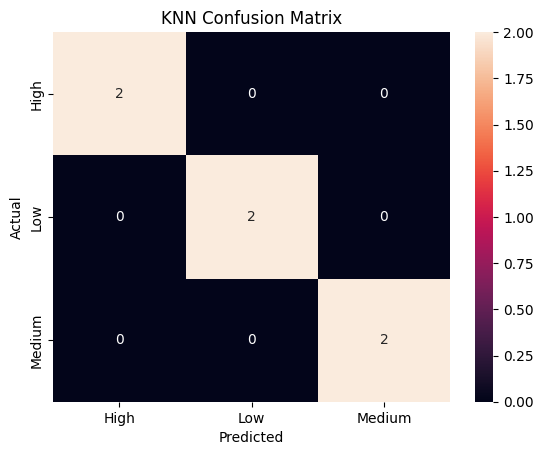

In [ ]:
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=knn.classes_,
    yticklabels=knn.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")

plt.show()

# Classification **Report**

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

        High       1.00      1.00      1.00         2
         Low       1.00      1.00      1.00         2
      Medium       1.00      1.00      1.00         2

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



# Predict a New **Student**

Study Hours       = 5.5 hours,
Attendance        = 88%,
Assignment Score  = 82,
Sleep Hours       = 7 hours

In [ ]:
new_student = [[5.5, 88, 82, 7]]

new_student_scaled = scaler.transform(new_student)

prediction = knn.predict(new_student_scaled)

print("Predicted Performance:", prediction[0])

Predicted Performance: High


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Experiment with Different Values of **K**

In [ ]:
k_values = [1, 3, 5, 7, 9]

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    prediction = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    print(
        "K =", k,
        "Accuracy =", accuracy
    )

K = 1 Accuracy = 1.0
K = 3 Accuracy = 1.0
K = 5 Accuracy = 1.0
K = 7 Accuracy = 0.6666666666666666
K = 9 Accuracy = 0.6666666666666666


# Plot K vs **Accuracy**

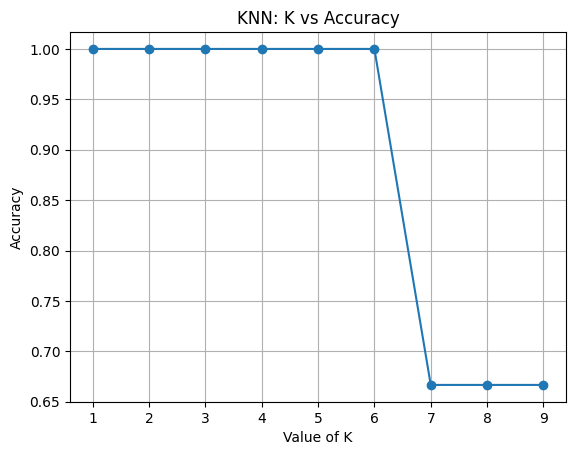

In [ ]:
k_values = range(1, 10)
accuracies = []

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    prediction = model.predict(
        X_test_scaled
    )

    accuracy = accuracy_score(
        y_test,
        prediction
    )

    accuracies.append(accuracy)

plt.plot(
    k_values,
    accuracies,
    marker='o'
)

plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.title("KNN: K vs Accuracy")
plt.xticks(k_values)
plt.grid()

plt.show()

# Visualize Two **Features**- Study Hours vs Assignment Score

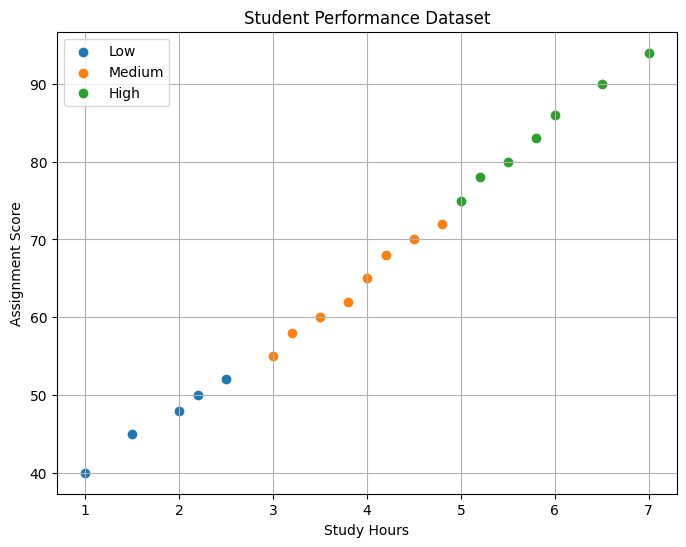

In [ ]:
plt.figure(figsize=(8, 6))

for performance in df['Performance'].unique():

    subset = df[
        df['Performance'] == performance
    ]

    plt.scatter(
        subset['Study_Hours'],
        subset['Assignment_Score'],
        label=performance
    )

plt.xlabel("Study Hours")
plt.ylabel("Assignment Score")
plt.title("Student Performance Dataset")
plt.legend()
plt.grid()

plt.show()